In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import holidays
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, make_scorer

## Data Import & Inspection

In [4]:
path = "../../raw_data/"
data_kim = pd.read_csv(f'{path}XGB_kim.csv')
data_javier = pd.read_csv(f'{path}XGB_javier.csv')

In [5]:
data_kim.head()

,DateTime(UTC),NetGeneration_MW,day_of_week,day_of_year,month,year,hour,quarter_hour,is_holiday,is_bridge_day,...,netgen_roll_std_24,netgen_roll_std_96,netgen_lag_1,netgen_lag_4,netgen_lag_12,netgen_lag_24,netgen_lag_96,netgen_lag_672,Price[Currency/MWh],target_288
0,2025-01-01 01:00:00,52168.44,2,1,1,2025,1,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.60,104.00
1,2025-01-01 01:15:00,51785.65,2,1,1,2025,1,1,1,0,...,NaN,NaN,52168.44,NaN,NaN,NaN,NaN,NaN,-0.50,72.59
2,2025-01-01 01:30:00,51121.02,2,1,1,2025,1,2,1,0,...,NaN,NaN,51785.65,NaN,NaN,NaN,NaN,NaN,-6.51,96.56
3,2025-01-01 01:45:00,50734.35,2,1,1,2025,1,3,1,0,...,NaN,NaN,51121.02,NaN,NaN,NaN,NaN,NaN,-3.50,102.41
4,2025-01-01 02:00:00,49814.90,2,1,1,2025,2,0,1,0,...,NaN,NaN,50734.35,52168.44,NaN,NaN,NaN,NaN,-1.05,102.40


In [6]:
data_kim.columns

Index(['DateTime(UTC)', 'NetGeneration_MW', 'day_of_week', 'day_of_year',
       'month', 'year', 'hour', 'quarter_hour', 'is_holiday', 'is_bridge_day',
       'netgen_roll_mean_4', 'netgen_roll_mean_24', 'netgen_roll_mean_96',
       'netgen_roll_mean_672', 'netgen_roll_std_4', 'netgen_roll_std_24',
       'netgen_roll_std_96', 'netgen_lag_1', 'netgen_lag_4', 'netgen_lag_12',
       'netgen_lag_24', 'netgen_lag_96', 'netgen_lag_672',
       'Price[Currency/MWh]', 'target_288'],
      dtype='object')

In [7]:
len(data_kim)

45413

In [8]:
data_kim.dropna(inplace=True)
len(data_kim)

44453

In [9]:
data_kim.head(1)

,DateTime(UTC),NetGeneration_MW,day_of_week,day_of_year,month,year,hour,quarter_hour,is_holiday,is_bridge_day,...,netgen_roll_std_24,netgen_roll_std_96,netgen_lag_1,netgen_lag_4,netgen_lag_12,netgen_lag_24,netgen_lag_96,netgen_lag_672,Price[Currency/MWh],target_288
672,2025-01-08 01:00:00,53980.39,2,8,1,2025,1,0,0,0,...,5172.737101,6682.835012,54971.24,55794.82,61869.39,70998.25,53459.05,52168.44,38.3,114.1


In [10]:
data_kim.tail(1)

,DateTime(UTC),NetGeneration_MW,day_of_week,day_of_year,month,year,hour,quarter_hour,is_holiday,is_bridge_day,...,netgen_roll_std_24,netgen_roll_std_96,netgen_lag_1,netgen_lag_4,netgen_lag_12,netgen_lag_24,netgen_lag_96,netgen_lag_672,Price[Currency/MWh],target_288
45124,2026-04-16 02:00:00,37055.13967,3,106,4,2026,2,0,0,0,...,1510.930014,2.298262e+07,37275.28835,37121.78868,38781.26126,40753.86738,35481.95706,47469.77942,102.92,105.96


In [11]:
##reading weather data
file_path = "../../raw_data/weather_avg.csv"
weather_df=pd.read_csv(file_path)

In [12]:
weather_df.head()

,temperature_c,humidity_percent,cloud_cover_percent,shortwave_radiation_wm2,DateTime(UTC)
0,0.800,78.75,80.75,0.0,2014-01-01 00:00:00
1,0.825,78.00,84.75,0.0,2014-01-01 01:00:00
2,0.825,78.25,91.50,0.0,2014-01-01 02:00:00
3,0.750,81.75,85.00,0.0,2014-01-01 03:00:00
4,0.675,84.50,92.75,0.0,2014-01-01 04:00:00


In [13]:
def merge_time_series_with_weather(
    main_df,
    weather_df,
    datetime_col="DateTime(UTC)",
    strategy="ffill"  # "ffill" or "interpolate"
    ):
        # -------------------------
    # 1. Convert datetime
    # -------------------------
    main_df = main_df.copy()
    weather_df = weather_df.copy()

    main_df[datetime_col] = pd.to_datetime(main_df[datetime_col])
    weather_df[datetime_col] = pd.to_datetime(weather_df[datetime_col])

    # -------------------------
    # 2. Set index
    # -------------------------
    main_df = main_df.set_index(datetime_col).sort_index()
    weather_df = weather_df.set_index(datetime_col).sort_index()

    # -------------------------
    # 3. Reindex weather to match main timeline
    # -------------------------
    weather_aligned = weather_df.reindex(main_df.index)

    # -------------------------
    # 4. Imputation strategy
    # -------------------------
    if strategy == "ffill":
        weather_aligned = weather_aligned.ffill()

    elif strategy == "interpolate":
        weather_aligned = weather_aligned.interpolate(method="time")

    else:
        raise ValueError("strategy must be either 'ffill' or 'interpolate'")

    # -------------------------
    # 5. Merge
    # -------------------------
    merged = main_df.join(weather_aligned)

    return merged.reset_index()

In [14]:
data_kim = merge_time_series_with_weather(
    data_kim,
    weather_df,
    strategy="interpolate"
)

## Feature manipulation

Cyclical encode repeated time-patterns

In [15]:
# remove the ordinal features and cyclical encode them
def cyclical_encode(df, col, max_val, offset=0, drop=True):
    sin_col = f"{col}_sin"
    cos_col = f"{col}_cos"

    df[sin_col] = np.sin(2 * np.pi * (df[col] - offset) / max_val)
    df[cos_col] = np.cos(2 * np.pi * (df[col] - offset) / max_val)

    if drop:
        df = df.drop(columns=[col])

    return df

# Apply to your dataframe
data_kim = cyclical_encode(data_kim, "quarter_hour", 4)
data_kim = cyclical_encode(data_kim, "hour", 24)
data_kim = cyclical_encode(data_kim, "day_of_week", 7)
data_kim = cyclical_encode(data_kim, "day_of_year", 365, offset=1)
data_kim = cyclical_encode(data_kim, "month", 12, offset=1)

Price[Currency/MWh]

In [16]:
# Rolling mean
data_kim["price_roll_mean_24"] = data_kim["Price[Currency/MWh]"].rolling(24).mean()
data_kim["price_roll_mean_96"] = data_kim["Price[Currency/MWh]"].rolling(96).mean()
data_kim["price_roll_mean_672"] = data_kim["Price[Currency/MWh]"].rolling(672).mean()

# Rolling std
data_kim["price_roll_std_4"] = data_kim["Price[Currency/MWh]"].rolling(4).std()
data_kim["price_roll_std_24"] = data_kim["Price[Currency/MWh]"].rolling(24).std()
data_kim["price_roll_std_96"] = data_kim["Price[Currency/MWh]"].rolling(96).std()

data_kim["price_lag_1"] = data_kim["Price[Currency/MWh]"].shift(1)
data_kim["price_lag_4"] = data_kim["Price[Currency/MWh]"].shift(4)
data_kim["price_lag_12"] = data_kim["Price[Currency/MWh]"].shift(12)   # 3 hours
data_kim["price_lag_24"] = data_kim["Price[Currency/MWh]"].shift(24)   # 6 hours
data_kim["price_lag_96"] = data_kim["Price[Currency/MWh]"].shift(96)   # 1 day
data_kim["price_lag_672"] = data_kim["Price[Currency/MWh]"].shift(672) # 1 week

In [17]:
data_kim.columns

Index(['DateTime(UTC)', 'NetGeneration_MW', 'year', 'is_holiday',
       'is_bridge_day', 'netgen_roll_mean_4', 'netgen_roll_mean_24',
       'netgen_roll_mean_96', 'netgen_roll_mean_672', 'netgen_roll_std_4',
       'netgen_roll_std_24', 'netgen_roll_std_96', 'netgen_lag_1',
       'netgen_lag_4', 'netgen_lag_12', 'netgen_lag_24', 'netgen_lag_96',
       'netgen_lag_672', 'Price[Currency/MWh]', 'target_288', 'temperature_c',
       'humidity_percent', 'cloud_cover_percent', 'shortwave_radiation_wm2',
       'quarter_hour_sin', 'quarter_hour_cos', 'hour_sin', 'hour_cos',
       'day_of_week_sin', 'day_of_week_cos', 'day_of_year_sin',
       'day_of_year_cos', 'month_sin', 'month_cos', 'price_roll_mean_24',
       'price_roll_mean_96', 'price_roll_mean_672', 'price_roll_std_4',
       'price_roll_std_24', 'price_roll_std_96', 'price_lag_1', 'price_lag_4',
       'price_lag_12', 'price_lag_24', 'price_lag_96', 'price_lag_672'],
      dtype='object')

## Modelling

In [18]:
start_date = pd.to_datetime("2025-02-01 00:00:00", format="%Y-%m-%d %H:%M:%S")
end_date = pd.to_datetime("2026-02-01 00:00:00", format="%Y-%m-%d %H:%M:%S")

In [19]:
data_kim["DateTime(UTC)"] =  pd.to_datetime(data_kim["DateTime(UTC)"], format="%Y-%m-%d %H:%M:%S")

In [20]:
data_12m = data_kim[(data_kim["DateTime(UTC)"] >= start_date) & (data_kim["DateTime(UTC)"] <= end_date)]

In [21]:
len(data_12m)

35041

In [22]:
data_12m["DateTime(UTC)"].min(), data_12m["DateTime(UTC)"].max()

(Timestamp('2025-02-01 00:00:00'), Timestamp('2026-02-01 00:00:00'))

In [ ]:
data_12m.columns

In [ ]:
#for running the VM, download data here
#data_12m.to_csv("grid_search_2.csv")

## Grid search

In [25]:
# ---------------------------
# 1. Prepare data
# ---------------------------


# Define target (3 days ahead = 288 steps)
target = 'target_288'

# Drop non-feature columns
drop_cols = ['DateTime(UTC)', 'Price[Currency/MWh]', target]
X = data_12m.drop(columns=drop_cols)
y = data_12m[target]

# ---------------------------
# 2. Time series split
# ---------------------------

tscv = TimeSeriesSplit(n_splits=5)

# ---------------------------
# 3. Define model
# ---------------------------

model = XGBRegressor(
    objective='reg:squarederror',
    tree_method='hist',   # fast for large datasets
    random_state=42
)

# ---------------------------
# 4. Hyperparameter grid
# ---------------------------

param_grid = {
    'n_estimators': [300, 600, 1000],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0],
    'gamma': [0, 0.1, 0.3],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 5, 10]
}

# ---------------------------
# 5. Scoring metric
# ---------------------------

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

# ---------------------------
# 6. Grid Search
# ---------------------------

random_search = RandomizedSearchCV(
    model,
    param_distributions=param_grid,
    n_iter=50,  # try 50–100 first
    scoring=mae_scorer,
    cv=tscv,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X, y)

# ---------------------------
# 7. Results
# ---------------------------

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest MAE:")
print(-random_search.best_score_)

# Best model
best_model = random_search.best_estimator_

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.05, max_depth=6, n_estimators=1000, reg_alpha=0, reg_lambda=10, subsample=0.9; total time=   6.0s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.1, max_depth=8, n_estimators=600, reg_alpha=1, reg_lambda=5, subsample=1.0; total time=   6.7s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.05, max_depth=6, n_estimators=1000, reg_alpha=0, reg_lambda=10, subsample=0.9; total time=   7.8s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.05, max_depth=6, n_estimators=1000, reg_alpha=0, reg_lambda=10, subsample=0.9; total time=   8.8s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.1, max_depth=8, n_estimators=600, reg_alpha=1, reg_lambda=5, subsample=1.0; total time=   8.9s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.1, max_depth=8, n_estimators=600, reg_alpha=1, reg_lambda=5, subsample=1.0; total time=   9.9s
[CV] END colsampl

In [27]:
# ---------------------------
# Data
# ---------------------------
df = data_12m.copy()
df = df.sort_values("DateTime(UTC)")

X = df.drop(columns=["Price[Currency/MWh]", "DateTime(UTC)"])
y = df["Price[Currency/MWh]"]

# ---------------------------
# Time series CV
# ---------------------------
tscv = TimeSeriesSplit(n_splits=5)

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

# ---------------------------
# Model (fixed regularization)
# ---------------------------
xgb = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42
)

# ---------------------------
# Focused parameter grid (HIGH IMPACT ONLY)
# ---------------------------

param_grid = {
    # tree complexity (VERY important)
    "max_depth": [4, 5, 6, 7],

    # learning dynamics (MOST important)
    "learning_rate": [0.005, 0.01, 0.02, 0.05],

    # boosting rounds
    "n_estimators": [300, 500, 800],

    # noise robustness (critical for electricity prices)
    "subsample": [0.7, 0.85, 1.0],

    # feature randomness (important due to many lag features)
    "colsample_bytree": [0.6, 0.75, 0.9]
}

# ---------------------------
# Grid search
# ---------------------------
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring=mae_scorer,
    cv=tscv,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X, y)

# ---------------------------
# Results
# ---------------------------
print("Best parameters:")
print(grid_search.best_params_)

print("\nBest MAE:")
print(-grid_search.best_score_)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
[CV] END colsample_bytree=0.6, learning_rate=0.005, max_depth=4, n_estimators=300, subsample=0.85; total time=   0.6s
[CV] END colsample_bytree=0.6, learning_rate=0.005, max_depth=4, n_estimators=300, subsample=0.7; total time=   0.7s
[CV] END colsample_bytree=0.6, learning_rate=0.005, max_depth=4, n_estimators=300, subsample=0.85; total time=   0.8s
[CV] END colsample_bytree=0.6, learning_rate=0.005, max_depth=4, n_estimators=300, subsample=0.7; total time=   0.9s
[CV] END colsample_bytree=0.6, learning_rate=0.005, max_depth=4, n_estimators=300, subsample=0.85; total time=   1.0s
[CV] END colsample_bytree=0.6, learning_rate=0.005, max_depth=4, n_estimators=300, subsample=0.7; total time=   1.0s
[CV] END colsample_bytree=0.6, learning_rate=0.005, max_depth=4, n_estimators=300, subsample=0.7; total time=   1.2s
[CV] END colsample_bytree=0.6, learning_rate=0.005, max_depth=4, n_estimators=300, subsample=0.85; total time=   1

## Fit and display results

### 1. Model after random and fixed Grid Search

In [36]:
grid_search.best_estimator_

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [37]:
# ---------------------------
# 2. Define target + features
# ---------------------------

target = 'target_288'

drop_cols = ['DateTime(UTC)', 'Price[Currency/MWh]', target]
X = data_12m.drop(columns=drop_cols)
y = data_12m[target]

# ---------------------------
# 3. Train / Test split
# ---------------------------

# Last 3 days = 288 timesteps
forecast_horizon = 288

X_train = X.iloc[:-forecast_horizon]
y_train = y.iloc[:-forecast_horizon]

X_test = X.iloc[-forecast_horizon:]
y_test = y.iloc[-forecast_horizon:]

# ---------------------------
# 4. Train final model
# ---------------------------
best_params = grid_search.best_params_

model = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    **best_params
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [38]:
y_pred = model.predict(X_test)

In [39]:
results = pd.DataFrame({
    "DateTime": data_12m['DateTime(UTC)'].iloc[-forecast_horizon:],
    "Actual_Price": data_12m['Price[Currency/MWh]'].iloc[-forecast_horizon:],
    "Predicted_Price": y_pred
})
results["DateTime_shifted"] = results["DateTime"] - pd.Timedelta(days=3)

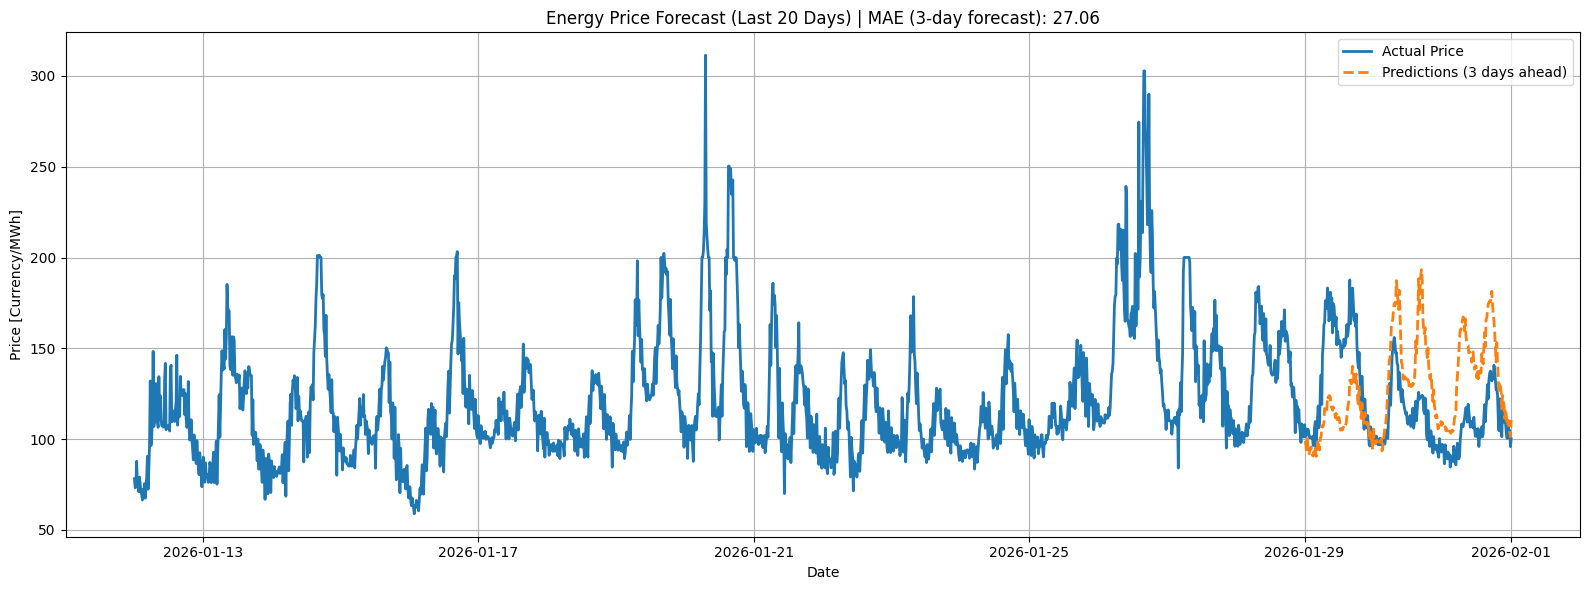

In [41]:
# ---------------------------
# Compute MAE
# ---------------------------

mae = mean_absolute_error(results["Actual_Price"], results["Predicted_Price"])

# ---------------------------
# 7. Plot last 20 days
# ---------------------------

# 20 days = 20 * 96 timesteps
plot_horizon = 20 * 96

plot_data = data_12m.iloc[-plot_horizon:].copy()

plt.figure(figsize=(16, 6))

# Actual prices
plt.plot(
    plot_data['DateTime(UTC)'],
    plot_data['Price[Currency/MWh]'],
    label='Actual Price',
    linewidth=2
)

# Predictions (only last 3 days)
plt.plot(
    results['DateTime'],
    results['Predicted_Price'],
    label='Predictions (3 days ahead)',
    linestyle='--',
    linewidth=2
)

# Predictions (shifted)
# plt.plot(
#     results['DateTime_shifted'],
#     results['Predicted_Price'],
#     label='Predictions (made 3 days earlier)',
#     linestyle='--',
#     linewidth=2
# )

plt.title(f'Energy Price Forecast (Last 20 Days) | MAE (3-day forecast): {mae:.2f}')
plt.xlabel('Date')
plt.ylabel('Price [Currency/MWh]')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### 2. Model before fixed and after random grid search

In [43]:
# ---------------------------
# 2. Define target + features
# ---------------------------

target = 'target_288'

drop_cols = ['DateTime(UTC)', 'Price[Currency/MWh]', target]
X = data_12m.drop(columns=drop_cols)
y = data_12m[target]

# ---------------------------
# 3. Train / Test split
# ---------------------------

# Last 3 days = 288 timesteps
forecast_horizon = 288

X_train = X.iloc[:-forecast_horizon]
y_train = y.iloc[:-forecast_horizon]

X_test = X.iloc[-forecast_horizon:]
y_test = y.iloc[-forecast_horizon:]

# ---------------------------
# 4. Train final model
# ---------------------------
best_params = random_search.best_params_

model = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    **best_params
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [44]:
results = pd.DataFrame({
    "DateTime": data_12m['DateTime(UTC)'].iloc[-forecast_horizon:],
    "Actual_Price": data_12m['Price[Currency/MWh]'].iloc[-forecast_horizon:],
    "Predicted_Price": y_pred
})
results["DateTime_shifted"] = results["DateTime"] - pd.Timedelta(days=3)

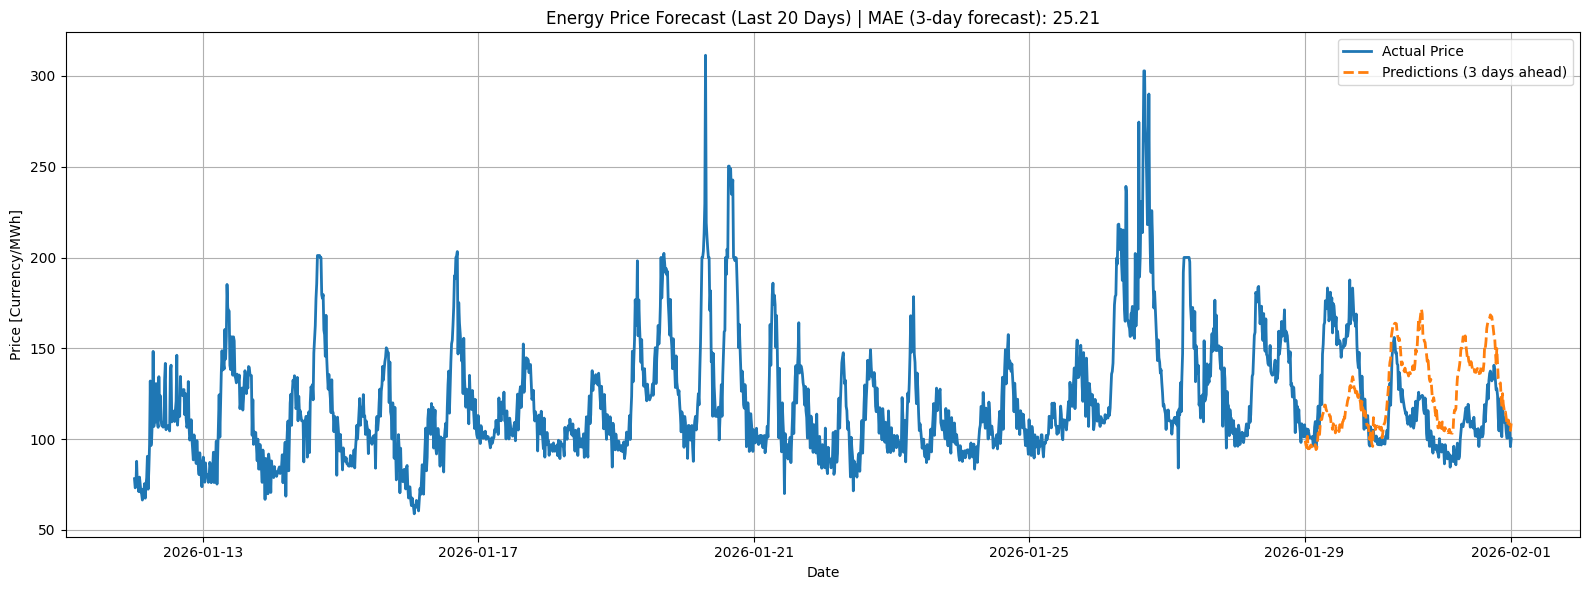

In [45]:
# ---------------------------
# Compute MAE
# ---------------------------

mae = mean_absolute_error(results["Actual_Price"], results["Predicted_Price"])

# ---------------------------
# 7. Plot last 20 days
# ---------------------------

# 20 days = 20 * 96 timesteps
plot_horizon = 20 * 96

plot_data = data_12m.iloc[-plot_horizon:].copy()

plt.figure(figsize=(16, 6))

# Actual prices
plt.plot(
    plot_data['DateTime(UTC)'],
    plot_data['Price[Currency/MWh]'],
    label='Actual Price',
    linewidth=2
)

# Predictions (only last 3 days)
plt.plot(
    results['DateTime'],
    results['Predicted_Price'],
    label='Predictions (3 days ahead)',
    linestyle='--',
    linewidth=2
)

# Predictions (shifted)
# plt.plot(
#     results['DateTime_shifted'],
#     results['Predicted_Price'],
#     label='Predictions (made 3 days earlier)',
#     linestyle='--',
#     linewidth=2
# )

plt.title(f'Energy Price Forecast (Last 20 Days) | MAE (3-day forecast): {mae:.2f}')
plt.xlabel('Date')
plt.ylabel('Price [Currency/MWh]')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()